In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from statsforecast import StatsForecast
from statsforecast.models import (Naive, WindowAverage, RandomWalkWithDrift,
                                   AutoARIMA, AutoETS, SeasonalNaive, SeasonalWindowAverage)
from utilsforecast.evaluation import evaluate
import utilsforecast.losses as ufl

c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


weekly_sales: merged sales
X_df : merged future data
df: reduced sales
df2: reduced future data

In [2]:
# Loading data
sales = pd.read_csv("sales_data.csv", parse_dates=["date"]).rename(columns={'date':'ds','store_id':'unique_id','sales':'y'})
future = pd.read_csv("future_values.csv", parse_dates=["date"]).rename(columns={'date':'ds','store_id':'unique_id'})
meta = pd.read_csv("metadata.csv").rename(columns={'store_id':'unique_id'})

C:\Users\pc\AppData\Local\Temp\ipykernel_16908\2847012046.py:2: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  sales = pd.read_csv("sales_data.csv", parse_dates=["date"]).rename(columns={'date':'ds','store_id':'unique_id','sales':'y'})


In [3]:
# Dummy encoding metadata
meta_encoded = pd.get_dummies(meta, columns=['store_type', 'assortment'], drop_first=True)
for col in meta_encoded.columns:
    if meta_encoded[col].dtype == bool:
        meta_encoded[col] = meta_encoded[col].astype(int)

meta_encoded.head()

,unique_id,competition_distance,store_type_b,store_type_c,store_type_d,assortment_b,assortment_c
0,store_1,1270.0,0,1,0,0,0
1,store_2,14130.0,0,0,0,0,0
2,store_3,24000.0,0,0,0,0,1
3,store_4,7520.0,0,0,0,0,0
4,store_5,2030.0,0,0,0,0,1


In [4]:
# Dummy encoding sales data
sales['state_holiday'] = sales['state_holiday'].astype(str)
sales = pd.get_dummies(sales, columns=['state_holiday'], prefix='holiday', drop_first=True)
for col in sales.columns:
    if col.startswith('holiday_') and sales[col].dtype == bool:
        sales[col] = sales[col].astype(int)

# Merging with metadata and aggregating to weekly
sales = sales.merge(meta_encoded, on='unique_id', how='left')
sales['ds'] = sales['ds'].dt.to_period('W').apply(lambda r: r.start_time) 

agg_sales = {
    'y': 'sum',
    'customers': 'sum',
    'open': 'mean',
    'promo': 'mean',
    'school_holiday': 'mean',
    'competition_distance': 'first',
    'holiday_a': 'sum',
    'holiday_b': 'sum',
    'holiday_c': 'sum',
    **{col: 'first' for col in meta_encoded.columns if col != 'unique_id'}
}

weekly_sales = sales.groupby(['unique_id', 'ds']).agg(agg_sales).reset_index()
weekly_sales['competition_distance'].fillna(weekly_sales['competition_distance'].median(), inplace=True)
weekly_sales.head()

C:\Users\pc\AppData\Local\Temp\ipykernel_16908\1696443983.py:26: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  weekly_sales['competition_distance'].fillna(weekly_sales['competition_distance'].median(), inplace=True)


,unique_id,ds,y,customers,open,promo,school_holiday,competition_distance,holiday_a,holiday_b,holiday_c,store_type_b,store_type_c,store_type_d,assortment_b,assortment_c
0,store_1,2013-01-07,32952,3918,0.857143,0.714286,0.714286,1270.0,0,0,0,0,1,0,0,0
1,store_1,2013-01-14,25978,3417,0.857143,0.000000,0.000000,1270.0,0,0,0,0,1,0,0,0
2,store_1,2013-01-21,33071,3862,0.857143,0.714286,0.000000,1270.0,0,0,0,0,1,0,0,0
3,store_1,2013-01-28,28693,3561,0.857143,0.000000,0.000000,1270.0,0,0,0,0,1,0,0,0
4,store_1,2013-02-04,35771,4094,0.857143,0.714286,0.000000,1270.0,0,0,0,0,1,0,0,0


In [5]:
# --- Prepare df for StatsForecast ---
#df = weekly_sales.rename(columns={'store_id': 'unique_id', 'week': 'ds', 'sales': 'y'})

#Dummy encoding, merging and aggregating of future data

future['state_holiday'] = future['state_holiday'].astype(str)
future = pd.get_dummies(future, columns=['state_holiday'], prefix='holiday', drop_first=True)
# Ensure all required holiday columns exist
for col in ['holiday_a', 'holiday_b', 'holiday_c']:
    if f'holiday_{col[-1]}' not in future.columns:
        future[f'holiday_{col[-1]}'] = 0

#for col in future.columns:
 #   if col.startswith('holiday_') and future[col].dtype == bool:
  #      future[col] = future[col].astype(int)

# One-hot encode state_holiday
#future = pd.get_dummies(future, columns=['state_holiday'], prefix='holiday', drop_first=False)

future = future.merge(meta_encoded, on='unique_id', how='left')
future['ds'] = future['ds'].dt.to_period('W').apply(lambda r: r.start_time)

agg_future = {
    'promo': 'mean',
    'school_holiday': 'mean',
    'customers': 'mean',
    'competition_distance': 'first',
    'holiday_a': 'sum',
    'holiday_b': 'sum',
    'holiday_c': 'sum',
    **{col: 'first' for col in meta_encoded.columns if col != 'unique_id'}
}

#weekly_future = future.groupby(['unique_id', 'week']).agg(agg_future).reset_index()
#X_df = weekly_future.rename(columns={'store_id': 'unique_id', 'week': 'ds'})
X_df = future.groupby(['unique_id', 'ds']).agg(agg_future).reset_index()
X_df.head()

,unique_id,ds,promo,school_holiday,customers,competition_distance,holiday_a,holiday_b,holiday_c,store_type_b,store_type_c,store_type_d,assortment_b,assortment_c
0,store_1,2015-07-20,0.000000,0.0,NaN,1270.0,0,0,0,0,1,0,0,0
1,store_1,2015-07-27,0.714286,1.0,NaN,1270.0,0,0,0,0,1,0,0,0
2,store_1,2015-08-03,0.714286,1.0,NaN,1270.0,0,0,0,0,1,0,0,0
3,store_1,2015-08-10,0.000000,1.0,NaN,1270.0,0,0,0,0,1,0,0,0
4,store_1,2015-08-17,0.714286,1.0,NaN,1270.0,0,0,0,0,1,0,0,0


In [6]:
# Defining models
models = [
    Naive(), 
    WindowAverage(window_size=12), 
    RandomWalkWithDrift(),
    AutoARIMA(season_length=52),
    AutoETS(season_length=52),
    SeasonalNaive(season_length=52),
    SeasonalWindowAverage(season_length=52, window_size=12)
]

sf = StatsForecast(models=models, freq='W')

In [7]:
# Transforming sales data to fix xreg is rank deficient error
df = weekly_sales.copy().drop(columns={'open'})

# Filter only store_1 to store_99 (inclusive)
first_100_stores = [f'store_{i}' for i in range(1, 100)]  # store_1 to store_99
df = df[df['unique_id'].isin(first_100_stores)]
df.to_csv("first_100.csv", index=False)

df.head()

,unique_id,ds,y,customers,promo,school_holiday,competition_distance,holiday_a,holiday_b,holiday_c,store_type_b,store_type_c,store_type_d,assortment_b,assortment_c
0,store_1,2013-01-07,32952,3918,0.714286,0.714286,1270.0,0,0,0,0,1,0,0,0
1,store_1,2013-01-14,25978,3417,0.000000,0.000000,1270.0,0,0,0,0,1,0,0,0
2,store_1,2013-01-21,33071,3862,0.714286,0.000000,1270.0,0,0,0,0,1,0,0,0
3,store_1,2013-01-28,28693,3561,0.000000,0.000000,1270.0,0,0,0,0,1,0,0,0
4,store_1,2013-02-04,35771,4094,0.714286,0.000000,1270.0,0,0,0,0,1,0,0,0


In [8]:
# Transforming future data to fix dimension error
df2 = X_df.copy()  #zırt pırt baştan yüklememek için değişimleri kopyasında yapıyorum 
first_99_stores = df['unique_id'].unique()[:99]
df2 = df2[df2['unique_id'].isin(first_99_stores)]

last_date = pd.to_datetime(df['ds'].max())
future_weeks = pd.date_range(start=last_date + pd.Timedelta(days=7), periods=8, freq='W-MON')

df2['ds'] = pd.to_datetime(df2['ds'])  # ensure type match
df2 = df2[df2['ds'].isin(future_weeks)]

# checking shape
print(f'Final X_df shape: {df2.shape}')
# Should be exactly (99 × 8, 14) → (792, 14)


Final X_df shape: (792, 14)


Cross v.  from exr. 7 

In [ ]:
# Create cross-validation and forecast into the future
models = [Naive(), WindowAverage(window_size=12), RandomWalkWithDrift(), AutoARIMA(season_length=52), AutoETS(season_length=52), SeasonalNaive(season_length=52), SeasonalWindowAverage(season_length=52, window_size=12)]
sf = StatsForecast(models=models, freq='W')
cv_df = sf.cross_validation(df=df, step_size=4, n_windows=5, h=8)
fc_df = sf.forecast(df=df, h=8, X_df=df2) 

ValueError: Models require the following exogenous features ['customers', 'promo', 'school_holiday', 'competition_distance', 'holiday_a', 'holiday_b', 'holiday_c', 'store_type_b', 'store_type_c', 'store_type_d', 'assortment_b', 'assortment_c'] for the forecasting step. Please provide them through `X_df`.

In [27]:
fc_df = sf.forecast(df=df, h=8, X_df=df2) 

In [28]:
# Calculate error metrics for cross-validation
metrics = evaluate(cv_df.drop(columns={'cutoff'}), metrics=[ufl.mse, ufl.mape])

In [ ]:
# Choose MSE for accuracy evaluation and prepare metrics data 
metric_for_selection = 'mse'
metrics = metrics[metrics.metric == metric_for_selection].drop('metric', axis=1)
metrics = metrics.melt(id_vars='unique_id', var_name='method', value_name='metric')
metrics = metrics.sort_values(['unique_id', 'metric'])

In [30]:
metrics

,unique_id,method,metric
297,store_1,AutoARIMA,0.025129
495,store_1,SeasonalNaive,0.073298
396,store_1,AutoETS,0.141803
99,store_1,WindowAverage,0.159279
0,store_1,Naive,0.163879
...,...,...,...
494,store_99,AutoETS,0.186619
197,store_99,WindowAverage,0.190837
98,store_99,Naive,0.216546
296,store_99,RWD,0.218822


In [31]:
# Function for calculating different ensemble types
def compute_ensemble_weights(df):
    df = df.copy()
    n_models = len(df)

    df['Best-Fit'] = 0.0
    df.iloc[0, df.columns.get_loc('Best-Fit')] = 1.0

    df['Equal-All'] = 1.0 / n_models

    df['Equal-Best3'] = 0.0
    top_n = min(3, n_models)
    df.iloc[:top_n, df.columns.get_loc('Equal-Best3')] = 1.0 / top_n

    inverse = 1.0 / df['metric']
    df['InverseMSE'] = inverse / inverse.sum()

    df['InverseMSE-Best3'] = 0.0
    top_n = min(3, n_models)
    inverse = 1.0 / df['metric'][:top_n]
    df.iloc[:top_n, df.columns.get_loc('InverseMSE-Best3')] = inverse / inverse.sum()

    long_weights = df.melt(
        id_vars=['method', 'unique_id'],
        value_vars=['Best-Fit', 'Equal-All', 'Equal-Best3', 'InverseMSE', 'InverseMSE-Best3'],
        var_name='ensemble_type',
        value_name='weight'
    )
    long_weights = long_weights[long_weights['weight'] > 0].reset_index(drop=True)

    return long_weights

In [32]:
# Create weights and multiply them with forecasts
weights_df = metrics.groupby('unique_id', group_keys=False).apply(compute_ensemble_weights)
forecasts_long = cv_df.melt(
    id_vars=['unique_id', 'ds', 'cutoff'],
    var_name='method',
    value_name='fc'
)
ensemble_fc = weights_df.merge(forecasts_long, how='left')
ensemble_fc['weighted_fc'] = ensemble_fc['fc'] * ensemble_fc['weight'] 
ensemble_fc = ensemble_fc.groupby(['unique_id', 'ensemble_type', 'ds', 'cutoff']).agg({'weighted_fc': 'sum'}).reset_index()
ensemble_fc = ensemble_fc.pivot(index=['unique_id', 'ds', 'cutoff'], values='weighted_fc', columns='ensemble_type').reset_index()

C:\Users\pc\AppData\Local\Temp\ipykernel_9480\1406636858.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weights_df = metrics.groupby('unique_id', group_keys=False).apply(compute_ensemble_weights)


In [ ]:
# Evaluate ensmeble and old models
full_fc = cv_df.merge(ensemble_fc)
metrics = evaluate(full_fc.drop(columns={'cutoff'}), metrics=[ufl.mse, ufl.mape])


In [37]:
full_fc.to_csv("full_fc1.csv", index=False)
metrics.to_csv("metrics1.csv", index=False)

In [ ]:
# Create ensmeble forecasts into the future using established weights, finally plot it
forecasts_long = fc_df.melt(
    id_vars=['unique_id', 'ds'],
    var_name='method',
    value_name='fc'
)
ensemble_fc = weights_df.merge(forecasts_long, how='left')
ensemble_fc['weighted_fc'] = ensemble_fc['fc'] * ensemble_fc['weight'] 
ensemble_fc = ensemble_fc.groupby(['unique_id', 'ensemble_type', 'ds']).agg({'weighted_fc': 'sum'}).reset_index()
ensemble_fc = ensemble_fc.pivot(index=['unique_id', 'ds'], values='weighted_fc', columns='ensemble_type').reset_index()



In [36]:
ensemble_fc.to_csv("ensemble_fc1.csv", index=False)

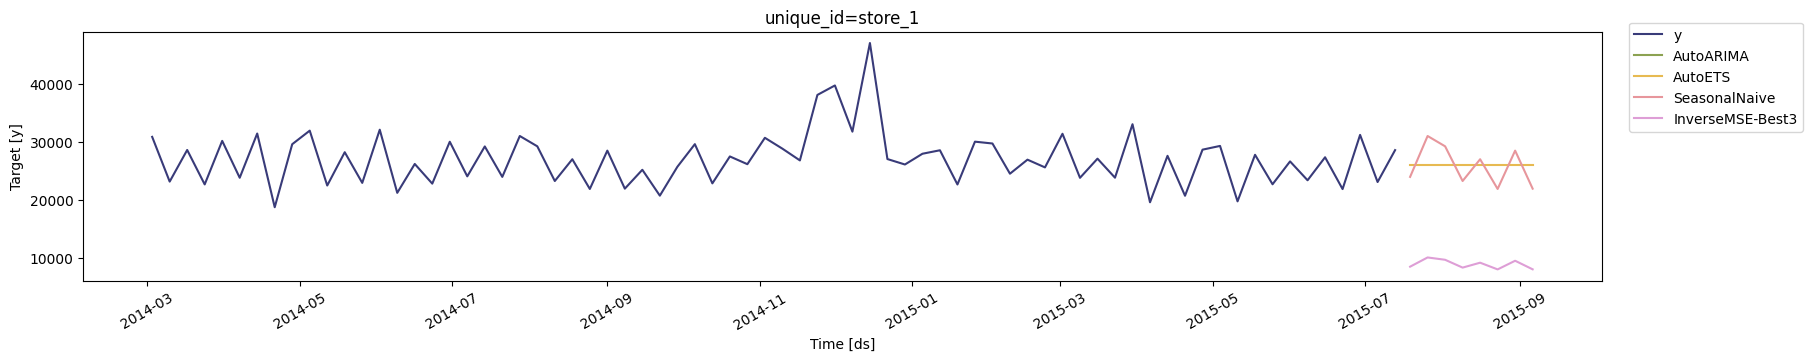

In [35]:
# Example plot
StatsForecast.plot(df=weekly_sales, forecasts_df=ensemble_fc.merge(ensemble_fc.merge(fc_df)), unique_ids=['store_1'],
                   models=['AutoARIMA', 'AutoETS', 'SeasonalNaive', 'InverseMSE-Best3'], max_insample_length=72)


------ exr 7 cv end ----- 

In [ ]:
# --- Cross-validation ChatGPT ---
cv_df = sf.cross_validation(df=df, step_size=4, n_windows=5, h=8)
cv_df.to_csv("cv_forecast_results.csv", index=False)

#29 dk sürdü

there are dimensional differences between sales data and future data which raises an error. correcting for the error 

In [20]:
df2 = X_df.copy()  #zırt pırt baştan yüklememek için değişimleri kopyasında yapıyorum 
first_99_stores = df['unique_id'].unique()[:99]
df2 = df2[df2['unique_id'].isin(first_99_stores)]

last_date = pd.to_datetime(df['ds'].max())
future_weeks = pd.date_range(start=last_date + pd.Timedelta(days=7), periods=8, freq='W-MON')

df2['ds'] = pd.to_datetime(df2['ds'])  # ensure type match
df2 = df2[df2['ds'].isin(future_weeks)]

# checking shape
print(f'Final X_df shape: {df2.shape}')
# Should be exactly (99 × 8, 14) → (792, 14)



Final X_df shape: (792, 14)


In [ ]:
# --- Final Forecast ---
fc_df = sf.forecast(df=df, h=8, X_df=df2)
fc_df.to_csv("final_forecast_results.csv", index=False)

print("Forecasting pipeline complete. Forecasts saved.")

Lecture 8 Random Forest 

In [9]:
import operator

import optuna
import pandas as pd

from mlforecast import MLForecast
from mlforecast.auto import AutoModel, AutoMLForecast
from mlforecast.lag_transforms import Combine, ExpandingMean, RollingMean
from mlforecast.target_transforms import Differences, LocalBoxCox
from statsforecast import StatsForecast
from sklearn.ensemble import RandomForestRegressor
from utilsforecast.evaluation import evaluate
import utilsforecast.losses as ufl

In [14]:
fcst = MLForecast(
    models=models,
    freq='W',
    lags=[1, 2, 4, 8],
    date_features=['weekofyear'],
    static_features=['store_type_b', 'store_type_c', 'store_type_d', 'assortment_b', 'assortment_c'],
    exogenous_features=['promo', 'school_holiday', 'holiday_a', 'holiday_b', 'holiday_c']
)




TypeError: MLForecast.__init__() got an unexpected keyword argument 'static_features'

## og 
fcst = MLForecast(
    models=models,
    freq='h',
    lags=[1, 2, 4, 8],   #weekly lags 
    date_features=['dayofweek', 'hour'],
    target_transforms=[Differences([1])],
    lag_transforms={
        1: [RollingMean(window_size=168)]
    }
)

In [18]:
## og 
fcst = MLForecast(
    models=models,
    freq='W',
    lags=[1, 2, 4, 8],   #weekly lags 
    date_features=['week'],
    target_transforms=[Differences([1])],
    lag_transforms={
        1: [RollingMean(window_size=2)]
    }
)

In [28]:
# 1. Drop static columns from df2,, fixing error for fcst.predict,, gives error bc of static features
static_cols = ['store_type_b', 'store_type_c', 'store_type_d', 'assortment_b', 'assortment_c']
dynamic_df = df2.drop(columns=static_cols, errors='ignore')

# 2. Create template with full horizon,, fixing error in prediction, not enough future variables for 8 week forecast 
future_template = fcst.make_future_dataframe(h=8)

# 3. Merge exogenous values onto it
df3 = future_template.merge(dynamic_df, on=['unique_id', 'ds'], how='left')

# 4. Forecast
fc_df = fcst.predict(h=8, X_df=df3)
fc_df.to_csv("rf_forecast_results.csv", index=False)


c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\mlforecast\core.py:625: UserWarning: Found null values in promo, school_holiday, customers, competition_distance, holiday_a, holiday_b, holiday_c.
  warnings.warn(f'Found null values in {", ".join(cols_with_nulls)}.')
c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\mlforecast\core.py:625: UserWarning: Found null values in promo, school_holiday, customers, competition_distance, holiday_a, holiday_b, holiday_c.
  warnings.warn(f'Found null values in {", ".join(cols_with_nulls)}.')
c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\mlforecast\core.py:625: UserWarning: Found null values in promo, school_holiday, customers, competition_distance, holiday_a, holiday_b, holiday_c.
  warnings.warn(f'Found null values in {", ".join(cols_with_nulls)}.')
c:\Users\pc\Desktop\Proje_2\BF-final\.venv\lib\site-packages\mlforecast\core.py:625: UserWarning: Found null values in promo, school_holiday, customers, competitio

# --- Predict future 8 weeks ---
fcst.fit(
    df,
    static_features=[
        'store_type_b', 'store_type_c', 'store_type_d',
        'assortment_b', 'assortment_c'
    ]
)

static_cols = ['store_type_b', 'store_type_c', 'store_type_d', 'assortment_b', 'assortment_c']
dynamic_df = df2.drop(columns=static_cols, errors='ignore') 

fc_df = fcst.predict(h=8, X_df=dynamic_df)
fc_df.to_csv("rf_forecast_results.csv", index=False)

# --- Predict future 8 weeks ---
# Run the forecast
print(fcst.preprocess(data))  # Just to take a look at the data, not necessary
fcst.fit(data)
fc_df = fcst.predict(h=8)
StatsForecast.plot(df=data, forecasts_df=fc_df, max_insample_length=24*7*10)

# Run a cross validation
# These specifications are too low / supoptimal, just an example and meant to imporve speed of this script
cv_df = fcst.cross_validation(df, n_windows=2, h=8)
metrics = [ufl.mse, ufl.mape]
metrics_df = evaluate(df=cv_df.drop(columns={'cutoff'}), metrics=metrics)
metrics_df
print('Cross-Validation finished. Running second half.')

# Specifying hyperparameter tuning
# These specifications are too low / supoptimal, just an example and meant to imporve speed of this script
def rf_config(trial: optuna.Trial):
    return {
        'n_estimators':  trial.suggest_int('n_estimators', 500, 800, step=100),
        'max_features': trial.suggest_int('max_features', 3, 5),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 8, 12)
    }
def rf_init_config(trial: optuna.Trial):
    return {
        'lags': [1, 2, 4, 8],
        'date_features': ['dayofweek', 'hour', 'month'],
        'target_transforms': [],  
        'lag_transforms': {
            1: [RollingMean(window_size=2),
                Combine(
                    RollingMean(window_size=2),
                    RollingMean(window_size=4),
                    operator.truediv)
                ],
            2: [RollingMean(window_size=2)]
        }
    }
def mse_trial(df, train_df):
   return ufl.mse(df, models=["model"])["model"].mean()
# Performing hyparameter tuning
# These specifications are too low / supoptimal, just an example and meant to imporve speed of this script
rf_tuned = AutoModel(
    model=RandomForestRegressor(),
    config=rf_config,
)
tuned_random_forest = AutoMLForecast(
    models={'rf_tuned': rf_tuned},
    freq='h',
    init_config=rf_init_config
).fit(
    df,
    n_windows=5,
    h=8,
    num_samples=2,  # number of combinations to try, should be considerably higher
    loss=mse_trial
)

# Investigating hyperparameter tuning
study = tuned_random_forest.results_['rf_tuned']
print(study.trials_dataframe().sort_values('value'))
print(study.best_params)

In [34]:
static_feats = [
    'store_type_b', 'store_type_c', 'store_type_d',
    'assortment_b', 'assortment_c'
]

#to include X_df in cross validation
df_combined = pd.concat([df, df3], axis=0).sort_values(['unique_id', 'ds'])

cv_df = fcst.cross_validation(
    df_combined,
    n_windows=4,
    step_size= 4,
    h=8,
    static_features=static_feats
)
metrics = [ufl.mse, ufl.mape]
metrics_df = evaluate(df=cv_df.drop(columns={'cutoff'}), metrics=metrics)
metrics_df
print('Cross-Validation finished. Running second half.')

# Specifying hyperparameter tuning
# These specifications are too low / supoptimal, just an example and meant to imporve speed of this script
def rf_config(trial: optuna.Trial):
    return {
        'n_estimators':  trial.suggest_int('n_estimators', 500, 800, step=100),
        'max_features': trial.suggest_int('max_features', 3, 5),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 8, 12)
    }
def rf_init_config(trial: optuna.Trial):
    return {
        'lags': [1, 2, 4, 8],
        'date_features': ['dayofweek', 'hour', 'month'],
        'target_transforms': [],  
        'lag_transforms': {
            1: [RollingMean(window_size=2),
                Combine(
                    RollingMean(window_size=3),
                    RollingMean(window_size=5),
                    operator.truediv)
                ],
            2: [RollingMean(window_size=3)]
        }
    }
def mse_trial(df, train_df):
   return ufl.mse(df, models=["model"])["model"].mean()
# Performing hyparameter tuning
# These specifications are too low / supoptimal, just an example and meant to imporve speed of this script
rf_tuned = AutoModel(
    model=RandomForestRegressor(),
    config=rf_config,
)
tuned_random_forest = AutoMLForecast(
    models={'rf_tuned': rf_tuned},
    freq='h',
    init_config=rf_init_config
).fit(
    df,
    n_windows=5,
    h=8,
    num_samples=2,  # number of combinations to try, should be considerably higher
    loss=mse_trial
)

# Investigating hyperparameter tuning
study = tuned_random_forest.results_['rf_tuned']
print(study.trials_dataframe().sort_values('value'))
print(study.best_params)

ValueError: Found missing inputs in X_df. It should have one row per id and time for the complete forecasting horizon.
You can get the expected structure by running `MLForecast.make_future_dataframe(h)` or get the missing combinatins in your current `X_df` by running `MLForecast.get_missing_future(h, X_df)`.